_Neural Data Science_

Lecturer: Dr. Jan Lause, Prof. Dr. Philipp Berens

Tutors: Jonas Beck, Fabio Seel, Julius Würzler

Summer term 2025

Student names: **Karim Zaghw, Kai Rothe, Mohammed Abbas Ansari**

LLM Disclaimer:  Yes, ChatGPT and Copilot was used in almost all the cell blocks to produce code. Modifications was done to LLM's output and care was taken to ensure desired outcome. 

# Coding Lab 7 : Transcriptomics

In [1]:
import numpy as np
import pylab as plt
import pandas as pd
import matplotlib.pyplot as plt

# We recommend using openTSNE for experiments with t-SNE
# https://github.com/pavlin-policar/openTSNE
from openTSNE import TSNE

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2025-06-07 10:42:11CEST

Python implementation: CPython
Python version       : 3.10.0
IPython version      : 8.35.0

sklearn: 1.6.1

openTSNE  : 1.0.2
pandas    : 2.2.3
numpy     : 1.24.4
matplotlib: 3.10.1

Watermark: 2.5.0



In [2]:
plt.style.use("../matplotlib_style.txt")

# Introduction

In this notebook you are going to work with transcriptomics data, in particular single-cell RNA sequencing (scRNA-seq) data from the paper by [Harris et al. (2018)](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.2006387). They recorded the transcriptomes of 3,663 inhibitory cells in the hippocampal area CA1. Their analysis divided these cells into 49 fine-scale clusters coresponding to different cell subtypes. They asigned names to these cluster in a hierarchical fashion according to strongly expressed gene in each clusters. The figure below shows the details of their classification. 

You will first analyze some of the most relevant statistics of UMI gene counts distributions, and afterwards follow the standard pipeline in the field to produce a visualization of the data.

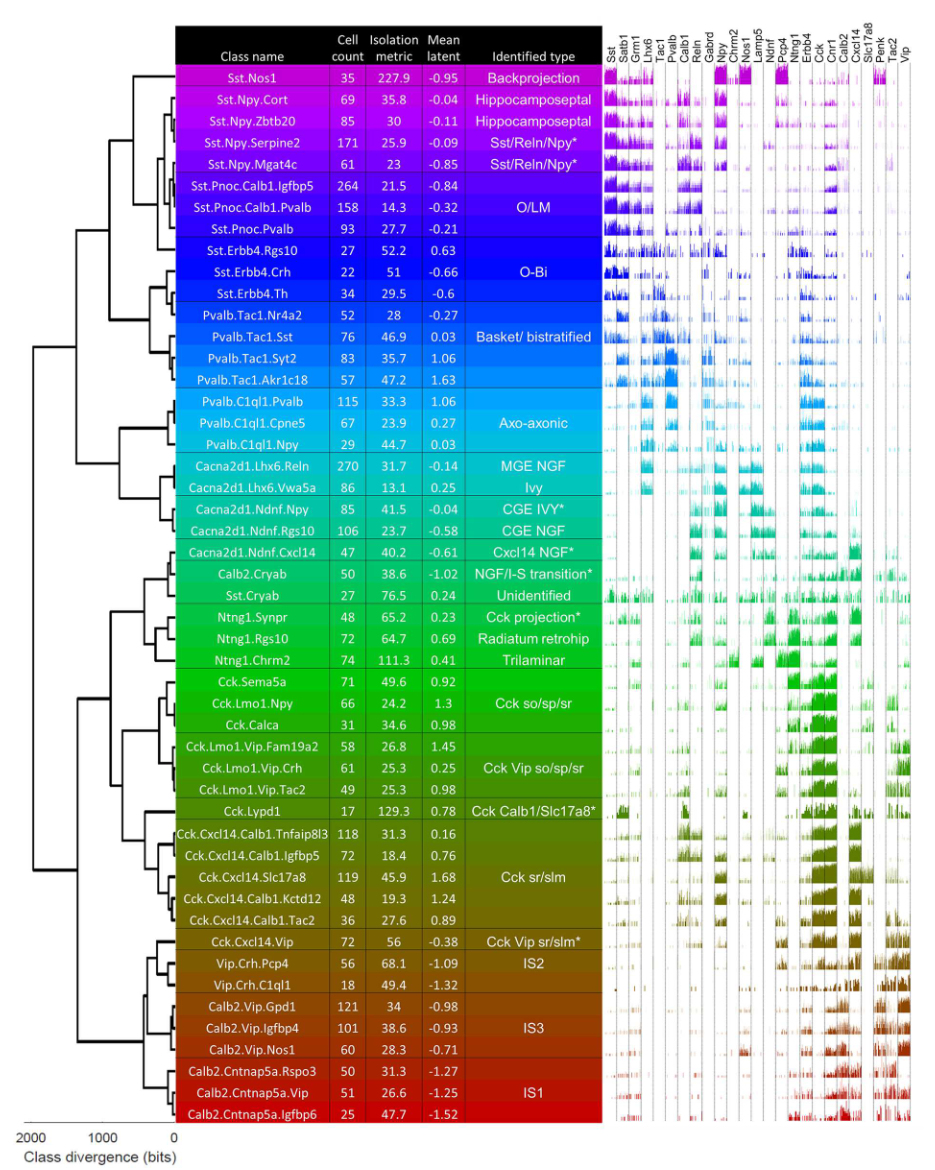

## Load data

Download the data from ILIAS, move it to the `data/` directory and unzip it there.
The read counts can be found in `counts`, with rows corresponding to cells and columns to genes.
The cluster assignments for every individual cell can be found in  `clusters`, along with the colors used in the publication in  `clusterColors`.

In [3]:
# LOAD HARRIS ET AL DATA

# Load gene counts
data = pd.read_csv("../data/nds_cl_7/harris-data/expression.tsv.gz", sep="\t")
genes = data.values[:, 0]
cells = data.columns[1:-1]
counts = data.values[:, 1:-1].transpose().astype("int")
data = []

# Kick out all genes with all counts = 0
genes = genes[counts.sum(axis=0) > 0]
counts = counts[:, counts.sum(axis=0) > 0]
print(counts.shape)

# Load clustering results
data = pd.read_csv("../data/nds_cl_7/harris-data/analysis_results.tsv", sep="\t")
clusterNames, clusters = np.unique(data.values[0, 1:-1], return_inverse=True)

# Load cluster colors
data = pd.read_csv("../data/nds_cl_7/harris-data/colormap.txt", sep="\s+", header=None)
clusterColors = data.values

# Note: the color order needs to be reversed to match the publication
clusterColors = clusterColors[::-1]

# Taken from Figure 1 - we need cluster order to get correct color order
clusterOrder = [
    "Sst.No",
    "Sst.Npy.C",
    "Sst.Npy.Z",
    "Sst.Npy.S",
    "Sst.Npy.M",
    "Sst.Pnoc.Calb1.I",
    "Sst.Pnoc.Calb1.P",
    "Sst.Pnoc.P",
    "Sst.Erbb4.R",
    "Sst.Erbb4.C",
    "Sst.Erbb4.T",
    "Pvalb.Tac1.N",
    "Pvalb.Tac1.Ss",
    "Pvalb.Tac1.Sy",
    "Pvalb.Tac1.A",
    "Pvalb.C1ql1.P",
    "Pvalb.C1ql1.C",
    "Pvalb.C1ql1.N",
    "Cacna2d1.Lhx6.R",
    "Cacna2d1.Lhx6.V",
    "Cacna2d1.Ndnf.N",
    "Cacna2d1.Ndnf.R",
    "Cacna2d1.Ndnf.C",
    "Calb2.Cry",
    "Sst.Cry",
    "Ntng1.S",
    "Ntng1.R",
    "Ntng1.C",
    "Cck.Sema",
    "Cck.Lmo1.N",
    "Cck.Calca",
    "Cck.Lmo1.Vip.F",
    "Cck.Lmo1.Vip.C",
    "Cck.Lmo1.Vip.T",
    "Cck.Ly",
    "Cck.Cxcl14.Calb1.Tn",
    "Cck.Cxcl14.Calb1.I",
    "Cck.Cxcl14.S",
    "Cck.Cxcl14.Calb1.K",
    "Cck.Cxcl14.Calb1.Ta",
    "Cck.Cxcl14.V",
    "Vip.Crh.P",
    "Vip.Crh.C1",
    "Calb2.Vip.G",
    "Calb2.Vip.I",
    "Calb2.Vip.Nos1",
    "Calb2.Cntnap5a.R",
    "Calb2.Cntnap5a.V",
    "Calb2.Cntnap5a.I",
]

reorder = np.zeros(clusterNames.size) * np.nan
for i, c in enumerate(clusterNames):
    for j, k in enumerate(clusterOrder):
        if c[: len(k)] == k:
            reorder[i] = j
            break
clusterColors = clusterColors[reorder.astype(int)]

(3663, 17965)


# Task 1: Data inspection
Before we use t-SNE or any other advanced visualization methods on the data, we first want to have a closer look on the data and plot some statistics. For most of the analysis we will compare the data to a Poisson distribution.

###  1.1. Relationship between expression mean and fraction of zeros
Compute actual and predicted gene expression. The higher the average expression of a gene, the smaller fraction of cells will show a 0 count. Plot the data and explain what you see in the plot.


_(3 pts)_

In [4]:
# ------------------------------------------------------
# Compute actual and predicted gene expression (1 pt)
# ------------------------------------------------------

# Compute the average expression for each gene
gene_means = counts.mean(axis=0)

# Compute the fraction of zeros for each gene
zero_fraction = (counts == 0).sum(axis=0) / counts.shape[0]

In [5]:
# Compute the Poisson prediction
# (what is the expected fraction of zeros in a Poisson distribution with a given mean?)
poisson_pred = np.exp(-gene_means)

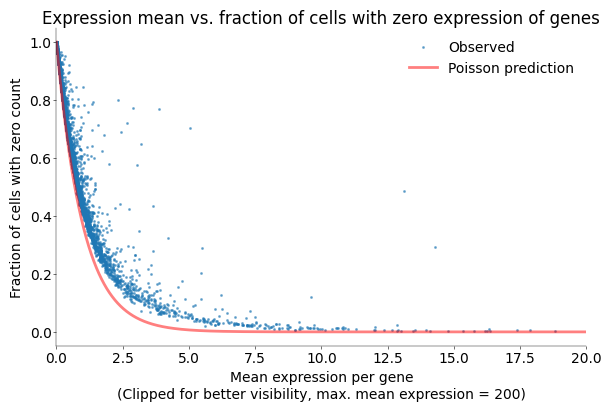

In [6]:
# --------------------------------------------------
# plot the data and the Poisson prediction (1 pt)
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
# add plot

# scatter of actual data
ax.scatter(gene_means, zero_fraction, s=5, alpha=0.5, label="Observed")

# overlay Poisson curve (sorted by mean for a smooth line)
sorted_idx = np.argsort(gene_means)
ax.plot(
    gene_means[sorted_idx],
    poisson_pred[sorted_idx],
    color="red",
    linewidth=2,
    alpha=0.5,
    label="Poisson prediction",
)

ax.set_xlabel(
    "Mean expression per gene\n(Clipped for better visibility, max. mean expression = 200)"
)
ax.set_ylabel("Fraction of cells with zero count")
ax.set_title("Expression mean vs. fraction of cells with zero expression of genes")
ax.set_xlim(0, 20)
ax.legend()
plt.show()

_Explanation (1 pt)_

The plot shows an inverse relationship between the mean expression of a gene and the fraction of cells in which that gene has zero counts. This has an intuitive explanation: if a gene is expressed on average more, there are probably more cells which express the gene. While this trend is expected under a Poisson model, the observed zero fractions (blue points) consistently lie above the red curve representing the Poisson-predicted zero fractions (i.e., $e^{−λ}$). This systematic deviation indicates zero inflation in the data. There are more zero counts than would be expected if gene expression followed a simple Poisson distribution. This suggests that many genes are either not expressed in certain subpopulations of cells because there a real biological differences or that technical limitations of single-cell RNA sequencing contribute to these excess zeros (e.g. variations of sequencing depth as a confounder).

### 1.2. Mean-variance relationship

If the expression follows Poisson distribution, then the mean should be equal to the variance. Plot the mean-variance relationship and interpret the plot.

_(2.5 pts)_

In [7]:
# -------------------------------------------------------------------
# Compute the variance of the expression counts of each gene (0.5 pt)
# -------------------------------------------------------------------
gene_vars = counts.var(axis=0)

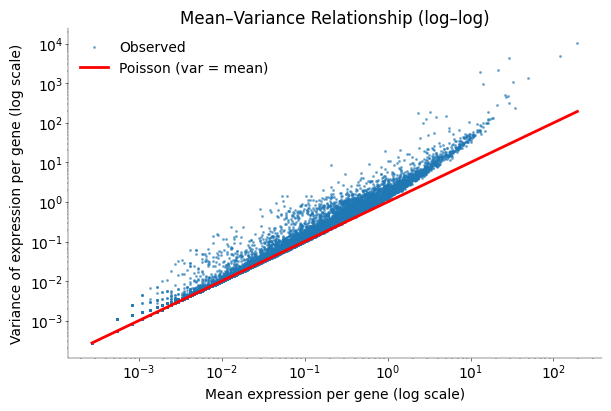

In [8]:
# -------------------------------------------------------------
# Plot the mean-variance relationship on a log-log plot (1 pt)
# Plot the Poisson prediction as a line
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))

# Scatter of observed mean vs. variance
ax.scatter(gene_means, gene_vars, s=5, alpha=0.5, label="Observed")

# Poisson prediction line
min_mean = gene_means[gene_means > 0].min()
max_mean = gene_means.max()
x_vals = np.logspace(np.log10(min_mean), np.log10(max_mean), 100)
y_vals = x_vals
ax.plot(x_vals, y_vals, color="red", linewidth=2, label="Poisson (var = mean)")

# Log-log scaling
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Mean expression per gene (log scale)")
ax.set_ylabel("Variance of expression per gene (log scale)")
ax.set_title("Mean–Variance Relationship (log–log)")
ax.legend()
plt.show()

_Explanation (1 pt)_

Almost every gene lies above the Poisson line (var = mean), showing that gene expression counts are consistently overdispersed. Their variance exceeds what a pure Poisson model predicts. This overdispersion grows with mean expression, so lowly expressed genes are only slightly above the Poisson expectation, whereas highly expressed genes show much larger excess variance. With this, we verify our previous observation. 

### 1.3. Relationship between the mean and the Fano factor

Compute the Fano factor for each gene and make a scatter plot of expression mean vs. Fano factor in log-log coordinates, and interpret what you see in the plot. If the expression follows the Poisson distribution, then the Fano factor (variance/mean) should be equal to 1 for all genes.

_(2.5 pts)_

In [9]:
# --------------------------------------------
# Compute the Fano factor for each gene (0.5 pt)
# --------------------------------------------

fano = gene_vars / gene_means

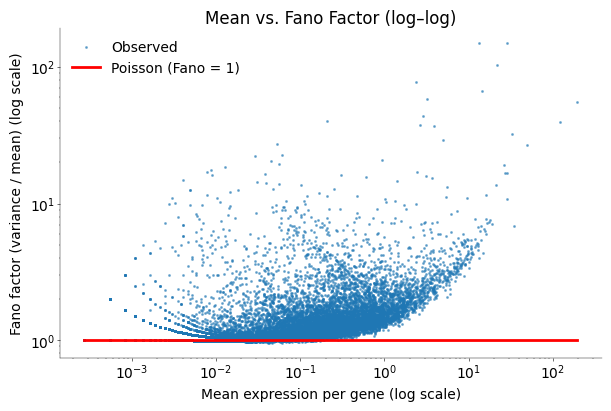

In [10]:
# -------------------------------
# plot fano-factor vs mean (1 pt)
# incl. fano factor
# -------------------------------
# Plot a Poisson prediction as line
# Use the same style of plot as above.

fig, ax = plt.subplots(figsize=(6, 4))

# Scatter of observed mean vs. Fano factor
ax.scatter(gene_means, fano, s=5, alpha=0.5, label="Observed")

# Poisson prediction line
min_mean = gene_means[gene_means > 0].min()
max_mean = gene_means.max()
x_vals = np.logspace(np.log10(min_mean), np.log10(max_mean), 100)
y_vals = np.ones_like(x_vals)
ax.plot(x_vals, y_vals, color="red", linewidth=2, label="Poisson (Fano = 1)")

# Log–log scaling
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Mean expression per gene (log scale)")
ax.set_ylabel("Fano factor (variance / mean) (log scale)")
ax.set_title("Mean vs. Fano Factor (log–log)")
ax.legend()
plt.show()

_Explanation (1 pt)_

Most genes lie well above the red Fano = 1 line, showing clear overdispersion relative to a Poisson model. Very low‐expression genes ($\text{mean} < 10^{-2}$) exhibit extremely large Fano factors because even a few nonzero counts inflate variance when divided by a tiny mean. Genes with moderate mean expression ($10^{-2} < \text{mean} < 1$) cluster just above Fano = 1, indicating only mild extra‐Poisson variability. Highly expressed genes ($1 < \text{mean}$) again show Fano factor much larger than 1. This fits with what we learned from the lecture: some highly variable genes actually differ between cell types but there is a also a model mismatch due to confounding variability not just due to noisy counting, i.e. non-Poisson noise.

### 1.4. Histogram of sequencing depths

Different cells have different sequencing depths (sum of counts across all genes) because the efficiency can change from droplet to droplet due to some random expreimental factors. Make a histogram of sequencing depths.

_(1.5 pts)_

In [11]:
# -------------------------------
# Compute sequencing depth (0.5 pt)
# -------------------------------

sequencing_depth = counts.sum(axis=1)

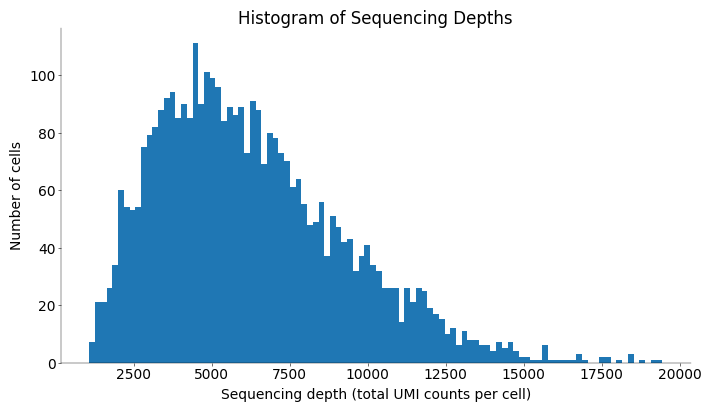

In [12]:
# ------------------------------------------
# Plot histogram of sequencing depths (1 pt)
# ------------------------------------------

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sequencing_depth, bins=100)
ax.set_xlabel("Sequencing depth (total UMI counts per cell)")
ax.set_ylabel("Number of cells")
ax.set_title("Histogram of Sequencing Depths")
plt.show()

### 1.5. Fano factors after normalization

Normalize counts by the sequencing depth of each cell and multiply by the median sequencing depth. Then make the same expression vs Fano factor plot as above. After normalization by sequencing depth, Fano factor should be closer to 1 (i.e. variance even more closely following the mean). This can be used for feature selection.

_(2.5 pts)_

In [13]:
# -------------------------------------------------
# compute normalized counts and fano factor (1 pt)
# -------------------------------------------------

median_depth = np.median(sequencing_depth)
counts_norm = counts * median_depth / sequencing_depth[:, None]

gene_means_norm = counts_norm.mean(axis=0)
gene_vars_norm = counts_norm.var(axis=0)
fano_norm = gene_vars_norm / gene_means_norm

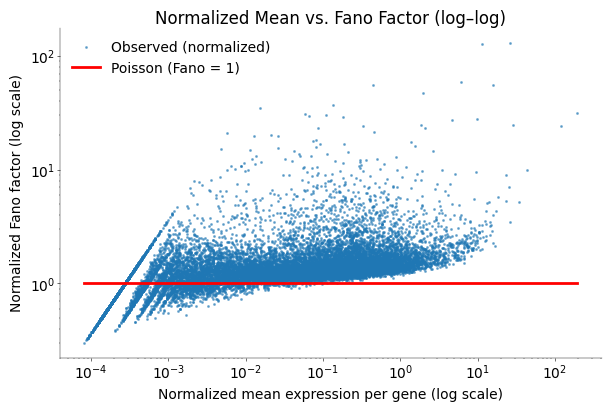

In [14]:
# ----------------------------------------------------------
# plot normalized counts and find the top 10 genes (1 pt)
# hint: keep appropriate axis scaling in mind
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 4))
# add plot

# Scatter of normalized mean vs. normalized Fano factor
ax.scatter(gene_means_norm, fano_norm, s=5, alpha=0.5, label="Observed (normalized)")

# Poisson prediction line: Fano factor = 1
min_mean_norm = gene_means_norm[gene_means_norm > 0].min()
max_mean_norm = gene_means_norm.max()
x_vals = np.logspace(np.log10(min_mean_norm), np.log10(max_mean_norm), 100)
y_vals = np.ones_like(x_vals)
ax.plot(x_vals, y_vals, color="red", linewidth=2, label="Poisson (Fano = 1)")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Normalized mean expression per gene (log scale)")
ax.set_ylabel("Normalized Fano factor (log scale)")
ax.set_title("Normalized Mean vs. Fano Factor (log–log)")
ax.legend()
plt.show()

As in the lecture, we find that normalizing the sequencing depth is a heuristic that reduces
the model mismatch, but does not fit perfectly, e.g. see gap between red horizontal line and observed points for high mean expression.

In [15]:
# --------------------------------------------------------------------
# Find top-10 genes with the highest normalized Fano factor (0.5 pts)
# Print them sorted by the Fano factor starting from the highest
# Gene names are stored in the `genes` array
# --------------------------------------------------------------------

top10_idx = np.argsort(fano_norm)[::-1][:10]
for idx in top10_idx:
    print(f"{genes[idx]}: {fano_norm[idx]:.2f}")

Sst: 131.14
Npy: 128.40
Vip: 59.11
Cck: 55.65
Cpne2: 55.22
Pcp4: 47.65
Ptpn23: 37.25
Pdzd9: 35.06
Malat1: 31.42
Armc2: 30.59


# Task 2: Low dimensional visualization

In this task we will construct a two dimensional visualization of the data. First we will normalize the data with some variance stabilizing transformation and study the effect that different approaches have on the data. Second, we will reduce the dimensionality of the data to a more feasible number of dimensions (e.g. $d=50$) using PCA. And last, we will project the PCA-reduced data to two dimensions using t-SNE.

### 2.1. PCA with and without transformations

Here we look at the influence of variance-stabilizing transformations on PCA. We will focus on the following transformations: 
- Square root (`sqrt(X)`): it is a variance-stabilizing transformation for the Poisson data. 
- Log-transform (`log2(X+1)`): it is also often used in the transcriptomic community. 

We will only work with the most important genes. For that, transform the counts into normalized counts (as above) and select all genes with normalized Fano factor above 3 and remove the rest. We will look at the effect that both transformations have in the PCA-projected data by visualizing the first two components. Interpret qualitatively what you see in the plot and compare the different embeddings making use of the ground truth clusters.

_(3.5 pts)_

In [16]:
# --------------------------------
# Select important genes (0.5 pts)
# --------------------------------
fano_threshold = 3
selected_genes_mask = fano_norm > fano_threshold
counts_norm_selected = counts_norm[:, selected_genes_mask]
genes_selected = genes[selected_genes_mask]

In [17]:
# --------------------------------------
# transform data and apply PCA (1 pt)
# --------------------------------------

from sklearn.decomposition import PCA

# perform PCA

# Initialize PCA to keep 50 components (as suggested)
pca = PCA(n_components=50)

# 1. PCA on normalized counts (no transformation)
X_norm = counts_norm_selected
pca_norm = pca.fit_transform(X_norm)

# 2. PCA on square root transformed data
X_sqrt = np.sqrt(counts_norm_selected)
pca_sqrt = pca.fit_transform(X_sqrt)

# 3. PCA on log2(X+1) transformed data
X_log = np.log2(counts_norm_selected + 1)
pca_log = pca.fit_transform(X_log)

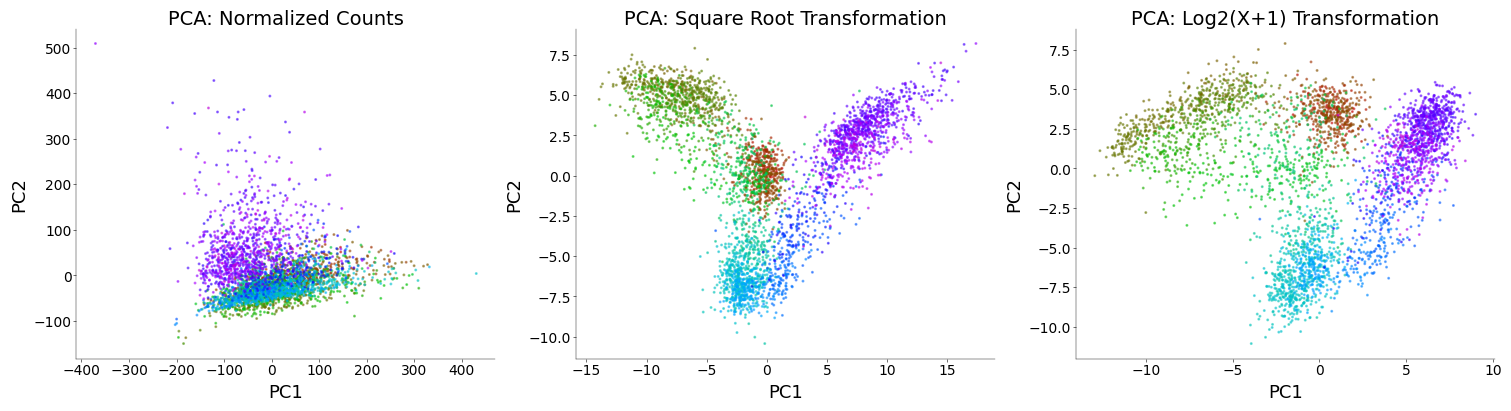

In [18]:
# ------------------------------------------------
# plot first 2 PCs for each transformation (1 pt)
# ------------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

# Scatter plot for normalized counts (no transformation)
axs[0].scatter(
    pca_norm[:, 0], pca_norm[:, 1], c=clusterColors[clusters], s=5, alpha=0.5
)
axs[0].set_xlabel("PC1", fontsize=13)
axs[0].set_ylabel("PC2", fontsize=13)
axs[0].set_title("PCA: Normalized Counts", fontsize=14)

# Scatter plot for square root transformation
axs[1].scatter(
    pca_sqrt[:, 0], pca_sqrt[:, 1], c=clusterColors[clusters], s=5, alpha=0.5
)
axs[1].set_xlabel("PC1", fontsize=13)
axs[1].set_ylabel("PC2", fontsize=13)
axs[1].set_title("PCA: Square Root Transformation", fontsize=14)

# Scatter plot for log2(X+1) transformation
axs[2].scatter(pca_log[:, 0], pca_log[:, 1], c=clusterColors[clusters], s=5, alpha=0.5)
axs[2].set_xlabel("PC1", fontsize=13)
axs[2].set_ylabel("PC2", fontsize=13)
axs[2].set_title("PCA: Log2(X+1) Transformation", fontsize=14)

plt.show()

_Explanation (1 pt)_

Both variance-stabilizing transformations (square root and log2) improve cluster separation compared to the untransformed normalized counts, as they mitigate the issue of high-variance genes dominating the PCA. The log2(X+1) transformation performs better than the square root transformation, as evidenced by the clearer separation of clusters in the PCA plot. This is likely because the log2 transformation more effectively compresses the dynamic range of expression values, making the data more suitable for linear dimensionality reduction like PCA. However, even with log2 transformation, some clusters overlap, indicating that PCA alone may not fully capture the complex, non-linear structure of scRNA-seq data, which motivates the use of non-linear methods like t-SNE in subsequent steps.

### 2.2. tSNE with and without transformations

Now, we will reduce the dimensionality of the PCA-reduced data further to two dimensions using t-SNE. We will use only $n=50$ components of the PCA-projected data. Plot the t-SNE embedding for the three versions of the data and interpret the plots. Do the different transformations have any effect on t-SNE?

_(1.5 pts)_

In [19]:
# -----------------------
# Perform tSNE (0.5 pts)
# -----------------------

# Initialize t-SNE with default parameters (perplexity=15, used in Harris et al.)
tsne = TSNE(n_components=2, perplexity=15, random_state=42)

# 1. t-SNE on PCA-reduced normalized counts (no transformation)
tsne_norm = tsne.fit(pca_norm)

# 2. t-SNE on PCA-reduced square root transformed data
tsne_sqrt = tsne.fit(pca_sqrt)

# 3. t-SNE on PCA-reduced log2(X+1) transformed data
tsne_log = tsne.fit(pca_log)

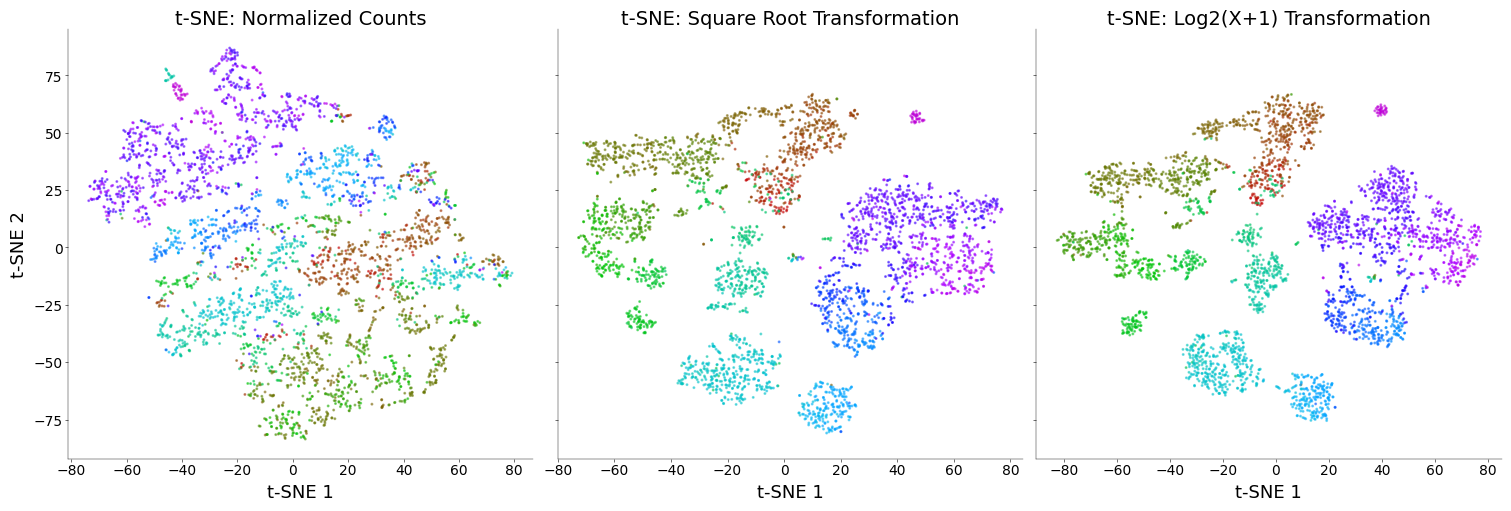

In [20]:
# -----------------------------------------------
# plot t-SNE embedding for each dataset (1 pt)
# -----------------------------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Scatter plot for t-SNE on normalized counts (no transformation)
axs[0].scatter(
    tsne_norm[:, 0], tsne_norm[:, 1], c=clusterColors[clusters], s=5, alpha=0.5
)
axs[0].set_xlabel("t-SNE 1", fontsize=13)
axs[0].set_ylabel("t-SNE 2", fontsize=13)
axs[0].set_title("t-SNE: Normalized Counts", fontsize=14)

# Scatter plot for t-SNE on square root transformed data
axs[1].scatter(
    tsne_sqrt[:, 0], tsne_sqrt[:, 1], c=clusterColors[clusters], s=5, alpha=0.5
)
axs[1].set_xlabel("t-SNE 1", fontsize=13)
axs[1].set_title("t-SNE: Square Root Transformation", fontsize=14)

# Scatter plot for t-SNE on log2(X+1) transformed data
axs[2].scatter(
    tsne_log[:, 0], tsne_log[:, 1], c=clusterColors[clusters], s=5, alpha=0.5
)
axs[2].set_xlabel("t-SNE 1", fontsize=13)
axs[2].set_title("t-SNE: Log2(X+1) Transformation", fontsize=14)

plt.show()

The transformations have a noticeable impact on the t-SNE embeddings, primarily through their effect on the PCA input. The log2(X+1) transformation yields the best cluster separation, followed (very closely) by the square root transformation, while the untransformed normalized counts show the least distinct clusters, but similar cells do inhabit similar regions. 

This is consistent with the PCA results from Task 2.1, where log2(X+1) also produced the clearest separation. The reason is that variance-stabilizing transformations reduce the influence of highly variable genes, allowing PCA to capture more meaningful variance, which t-SNE then uses to preserve local structures (neighborhoods) in the 2D embedding. Unlike PCA, t-SNE is non-linear and focuses on local similarities, so the improved input from variance-stabilized data enhances its ability to reflect the true cell type structure. However, t-SNE’s sensitivity to initialization and hyperparameters (e.g., perplexity) means that some differences may also arise from its optimization process, but the transformations clearly improve the input data quality.

### 2.3. Leiden clustering

Now we will play around with some clustering and see whether the clustering methods can produce similar results to the original clusters from the publication. We will apply Leiden clustering (closely related to the Louvain clustering), which is standard in the field and works well even for very large datasets. 

Choose one representation of the data (best transformation based in your results from the previous task) to use further in this task and justify your choice. Think about which level of dimensionality would be sensible to use to perform clustering. Visualize in the two-dimensional embedding the resulting clusters and compare to the original clusters. 

_(1.5 pts)_

In [21]:
# To run this code you need to install leidenalg and igraph
# conda install -c conda-forge python-igraph leidenalg

import igraph as ig
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
import leidenalg as la

In [22]:
# Define some contrast colors

clusterCols = [
    "#FFFF00",
    "#1CE6FF",
    "#FF34FF",
    "#FF4A46",
    "#008941",
    "#006FA6",
    "#A30059",
    "#FFDBE5",
    "#7A4900",
    "#0000A6",
    "#63FFAC",
    "#B79762",
    "#004D43",
    "#8FB0FF",
    "#997D87",
    "#5A0007",
    "#809693",
    "#FEFFE6",
    "#1B4400",
    "#4FC601",
    "#3B5DFF",
    "#4A3B53",
    "#FF2F80",
    "#61615A",
    "#BA0900",
    "#6B7900",
    "#00C2A0",
    "#FFAA92",
    "#FF90C9",
    "#B903AA",
    "#D16100",
    "#DDEFFF",
    "#000035",
    "#7B4F4B",
    "#A1C299",
    "#300018",
    "#0AA6D8",
    "#013349",
    "#00846F",
    "#372101",
    "#FFB500",
    "#C2FFED",
    "#A079BF",
    "#CC0744",
    "#C0B9B2",
    "#C2FF99",
    "#001E09",
    "#00489C",
    "#6F0062",
    "#0CBD66",
    "#EEC3FF",
    "#456D75",
    "#B77B68",
    "#7A87A1",
    "#788D66",
    "#885578",
    "#FAD09F",
    "#FF8A9A",
    "#D157A0",
    "#BEC459",
    "#456648",
    "#0086ED",
    "#886F4C",
    "#34362D",
    "#B4A8BD",
    "#00A6AA",
    "#452C2C",
    "#636375",
    "#A3C8C9",
    "#FF913F",
    "#938A81",
    "#575329",
    "#00FECF",
    "#B05B6F",
    "#8CD0FF",
    "#3B9700",
    "#04F757",
    "#C8A1A1",
    "#1E6E00",
    "#7900D7",
    "#A77500",
    "#6367A9",
    "#A05837",
    "#6B002C",
    "#772600",
    "#D790FF",
    "#9B9700",
    "#549E79",
    "#FFF69F",
    "#201625",
    "#72418F",
    "#BC23FF",
    "#99ADC0",
    "#3A2465",
    "#922329",
    "#5B4534",
    "#FDE8DC",
    "#404E55",
    "#0089A3",
    "#CB7E98",
    "#A4E804",
    "#324E72",
    "#6A3A4C",
    "#83AB58",
    "#001C1E",
    "#D1F7CE",
    "#004B28",
    "#C8D0F6",
    "#A3A489",
    "#806C66",
    "#222800",
    "#BF5650",
    "#E83000",
    "#66796D",
    "#DA007C",
    "#FF1A59",
    "#8ADBB4",
    "#1E0200",
    "#5B4E51",
    "#C895C5",
    "#320033",
    "#FF6832",
    "#66E1D3",
    "#CFCDAC",
    "#D0AC94",
    "#7ED379",
    "#012C58",
]

clusterCols = np.array(clusterCols)

In [23]:
# ------------------------------------------------------
# create graph and run leiden clustering on it (0.5 pts)
# hint: use `la?`, `la.find_partition?` and `ig.Graph?`
# to find out more about the provided packages.
# ------------------------------------------------------

# Construct kNN graph with k=15
k = 15
n_pca = 50
X_clustering = pca_log[:, :n_pca]  # Use PCA-reduced data for clustering
A = kneighbors_graph(
    X_clustering, n_neighbors=k, mode="connectivity", include_self=False
)

# Transform it into an igraph object
sources, targets = A.nonzero()
graph = ig.Graph(edges=list(zip(sources, targets)), directed=False)

# Run Leiden clustering
# you can use `la.RBConfigurationVertexPartition` as the partition type
partition = la.find_partition(
    graph, la.RBConfigurationVertexPartition, resolution_parameter=1.0
)
leiden_clusters_default_res = np.array(partition.membership)

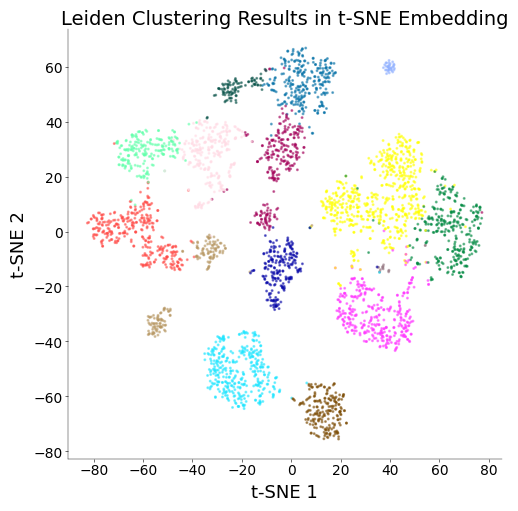

In [24]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

fig, ax = plt.subplots(figsize=(5, 5))
scatter = ax.scatter(
    tsne_log[:, 0],
    tsne_log[:, 1],
    c=clusterCols[leiden_clusters_default_res],
    s=5,
    alpha=0.5,
)
ax.set_xlabel("t-SNE 1", fontsize=13)
ax.set_ylabel("t-SNE 2", fontsize=13)
ax.set_title("Leiden Clustering Results in t-SNE Embedding", fontsize=14)

plt.show()

The log2(X+1) transformation was chosen because it provided the clearest separation of clusters in PCA and t-SNE embeddings. Using PCA-reduced data with a reduced number of components ensures efficient clustering of the most biologically relevant variation while discarding technical and random fluctuations, while a too reduced number of components might fail to capture the ground-truth clustering structure. We find a dimension of 50 to be efficient and not overly noisy. The Leiden clustering results align mostly well with the original clusters, as visualized in the t-SNE embedding, demonstrating the effectiveness of this approach for scRNA-seq data. 

### 2.4. Change the clustering resolution

The number of clusters can be changed by modifying the resolution parameter. How many clusters did we get with the default value? Change the resolution parameter to yield 2x more and 2x fewer clusters
Plot all three results as t-SNE overlays (same as above).

_(1.5 pts)_

In [25]:
# ------------------------------------------------------------------
# run the clustering for 3 different resolution parameters (0.5 pts)
# ------------------------------------------------------------------

# 2x more clusters
partition_high_res = la.find_partition(
    graph, la.RBConfigurationVertexPartition, resolution_parameter=2.0
)
leiden_clusters_high_res = np.array(partition_high_res.membership)

# 2x fewer clusters
partition_low_res = la.find_partition(
    graph, la.RBConfigurationVertexPartition, resolution_parameter=0.5
)
leiden_clusters_low_res = np.array(partition_low_res.membership)

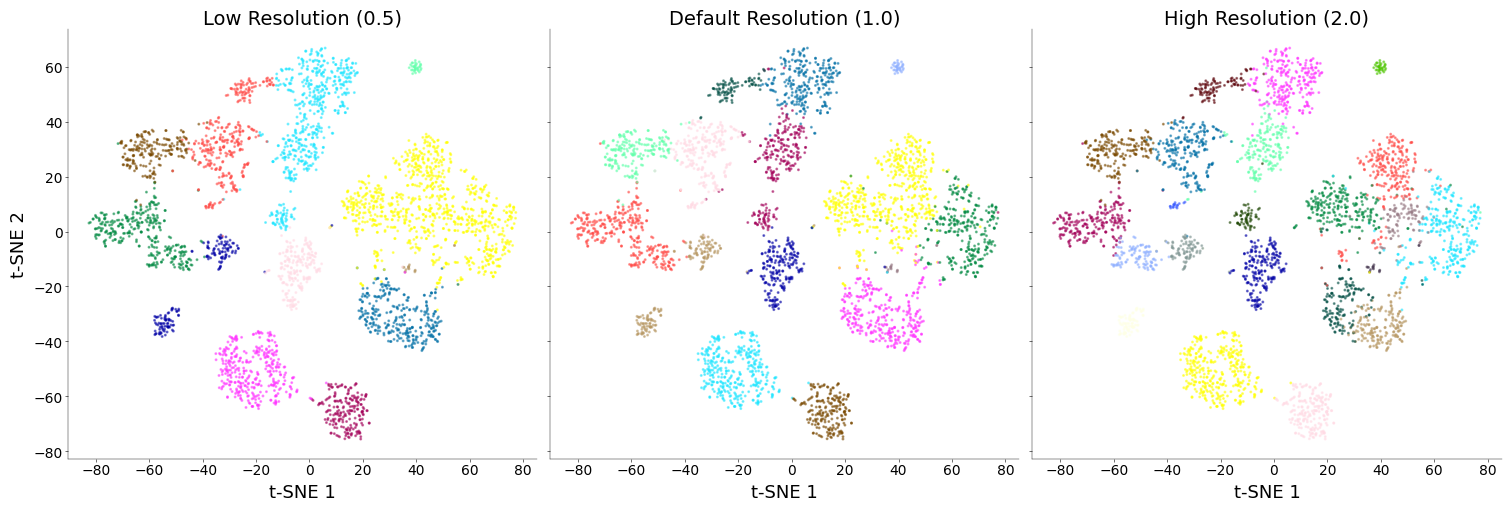

In [26]:
# --------------------------
# Plot the results (1 pt)
# --------------------------

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# 2x fewer clusters
axs[0].scatter(
    tsne_log[:, 0],
    tsne_log[:, 1],
    c=clusterCols[leiden_clusters_low_res],
    s=5,
    alpha=0.5,
)
axs[0].set_title("Low Resolution (0.5)", fontsize=14)
axs[0].set_xlabel("t-SNE 1", fontsize=13)
axs[0].set_ylabel("t-SNE 2", fontsize=13)

# Default resolution
axs[1].scatter(
    tsne_log[:, 0],
    tsne_log[:, 1],
    c=clusterCols[leiden_clusters_default_res],
    s=5,
    alpha=0.5,
)
axs[1].set_title("Default Resolution (1.0)", fontsize=14)
axs[1].set_xlabel("t-SNE 1", fontsize=13)

# 2x more clusters
axs[2].scatter(
    tsne_log[:, 0],
    tsne_log[:, 1],
    c=clusterCols[leiden_clusters_high_res],
    s=5,
    alpha=0.5,
)
axs[2].set_title("High Resolution (2.0)", fontsize=14)
axs[2].set_xlabel("t-SNE 1", fontsize=13)

plt.show()

We find that low resolution matches the data better, finding fewer and larger clusters (halfed resolution) which resembles the clustering by Harris et. al. closer. Higher resolution introduces more and smaller clusters, which are not distinguishible by eye in the 2D t-SNE visualization. 